# Figure S3

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import ttest_ind

# for converting cielab to LCh
from colormath.color_objects import LabColor, LCHabColor
from colormath.color_conversions import convert_color

# for the 3d histogram
from mpl_toolkits.mplot3d import Axes3D
from skimage.color import lab2rgb

In [2]:
color_df = pd.read_csv('../datasets/1-clusters/geo_med.csv')

In [3]:
color_df_reduced = (
    color_df.groupby("gbifID", sort=False, group_keys=False)
    .apply(lambda x: x.sample(1,random_state=123))
    .reset_index(drop=True)
)
color_df_reduced

/var/folders/qh/c7rwx84921n2kznn09zb2pnh0000gn/T/ipykernel_98246/1712891894.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(1,random_state=123))


,image_idx,hex,rgb,hsl,lab,gbifID,identifier,latitude,longitude
0,0,#d4b4e2,"(212, 180, 226)","(0.782608695652174, 0.44230769230769224, 0.796...","(197, 148, 109)",923911394,https://inaturalist-open-data.s3.amazonaws.com...,48.826305,-102.092171
1,2,#cdb3cd,"(205, 179, 205)","(0.8333333333333334, 0.2063492063492065, 0.752...","(193, 142, 118)",923910407,https://inaturalist-open-data.s3.amazonaws.com...,43.613086,-73.057076
2,4,#bda5d7,"(189, 165, 215)","(0.7466666666666667, 0.3846153846153846, 0.745...","(182, 146, 106)",899970365,https://inaturalist-open-data.s3.amazonaws.com...,43.066871,-87.890565
3,7,#9984ae,"(153, 132, 174)","(0.75, 0.2058823529411765, 0.6000000000000001)","(149, 144, 109)",891778924,https://inaturalist-open-data.s3.amazonaws.com...,42.140556,-87.831643
4,9,#ba9fdd,"(186, 159, 221)","(0.739247311827957, 0.476923076923077, 0.74509...","(178, 150, 100)",891760719,https://inaturalist-open-data.s3.amazonaws.com...,38.679240,-97.990035
...,...,...,...,...,...,...,...,...,...
16582,41059,#a191c2,"(161, 145, 194)","(0.7210884353741497, 0.2865497076023391, 0.664...","(161, 144, 105)",1024218211,https://inaturalist-open-data.s3.amazonaws.com...,41.569419,-88.150552
16583,41060,#b77fb7,"(183, 127, 183)","(0.8333333333333334, 0.28, 0.607843137254902)","(154, 159, 107)",1024202810,https://inaturalist-open-data.s3.amazonaws.com...,45.057871,-87.168277
16584,41061,#af96cb,"(175, 150, 203)","(0.7452830188679246, 0.3375796178343948, 0.692...","(168, 148, 104)",1024200169,https://inaturalist-open-data.s3.amazonaws.com...,42.921738,-88.026752
16585,41063,#c5b9b2,"(197, 185, 178)","(0.06140350877192979, 0.1407407407407409, 0.73...","(194, 131, 133)",1024198670,https://inaturalist-open-data.s3.amazonaws.com...,40.791723,-80.492498


### add separate component rows

In [4]:
L = [(int(i.strip('()').split(', ')[0])) for i in color_df_reduced.lab]
L = (np.array(L) / 255.0) * 100.0  
color_df_reduced['L'] = L
a = [(int(i.strip('()').split(', ')[1])) for i in color_df_reduced.lab]
a = np.array(a) - 128.0  
color_df_reduced['a'] = a
b = [(int(i.strip('()').split(', ')[2])) for i in color_df_reduced.lab]
b = np.array(b) - 128.0
color_df_reduced['b'] = b

## get LCh values as well

In [5]:
lab_vals = np.array(color_df_reduced[['L','a','b']])

lch_arr = np.empty_like(lab_vals)
for i, (L_, a_, b_) in enumerate(lab_vals):
    # had to think carefully here -- these look like the correct defaults
    # rather than d50 illuminant because of I used opencv at its default
    lab = LabColor(L_, a_, b_, observer='2', illuminant='d65') 
    lch = convert_color(lab, LCHabColor)
    lch_arr[i] = lch.get_value_tuple()

In [6]:
color_df_reduced['lch_l'] = lch_arr[:,0]
color_df_reduced['lch_c'] = lch_arr[:,1]
color_df_reduced['lch_h'] = lch_arr[:,2]

### add region

In [7]:
# set region split longitude
focal_lon = -100 
# make a "region" column based on longitude
color_df_reduced['region'] = color_df_reduced['longitude'].apply(lambda x: 'East' if x > focal_lon else 'West')

# Plot 3D histograms to better capture density of purples relative to other outlier colors

In [8]:
# bin definitions
num_x_bins = 30
num_y_bins = 30
# make the actual histogram object
hist, xedges, yedges = np.histogram2d(color_df_reduced['lch_c'], color_df_reduced['lch_h'], bins=[num_x_bins, num_y_bins],range=[[0,145],[0,360]])

# the the center of each bin
a_centers = (xedges[:-1] + xedges[1:]) / 2
b_centers = (yedges[:-1] + yedges[1:]) / 2

# pick a default L for all bins -- this is arbitrary -- we're just looking at hue differences here
default_L = 70#L.mean()

In [9]:
# build mean_lch grid
mean_lch = np.zeros((num_x_bins, num_y_bins, 3), dtype=float)
for i in range(num_x_bins):
    for j in range(num_y_bins):
        mean_lch[i, j] = [ default_L,
                           a_centers[i],
                           b_centers[j] ]


In [10]:
mean_lab = np.zeros_like(mean_lch)
for row in range(mean_lab.shape[0]):
    for col in range(mean_lab.shape[0]):
        conv_color = convert_color(LCHabColor(*mean_lch[row,col]),LabColor)
        mean_lab[row,col] = conv_color.get_value_tuple()

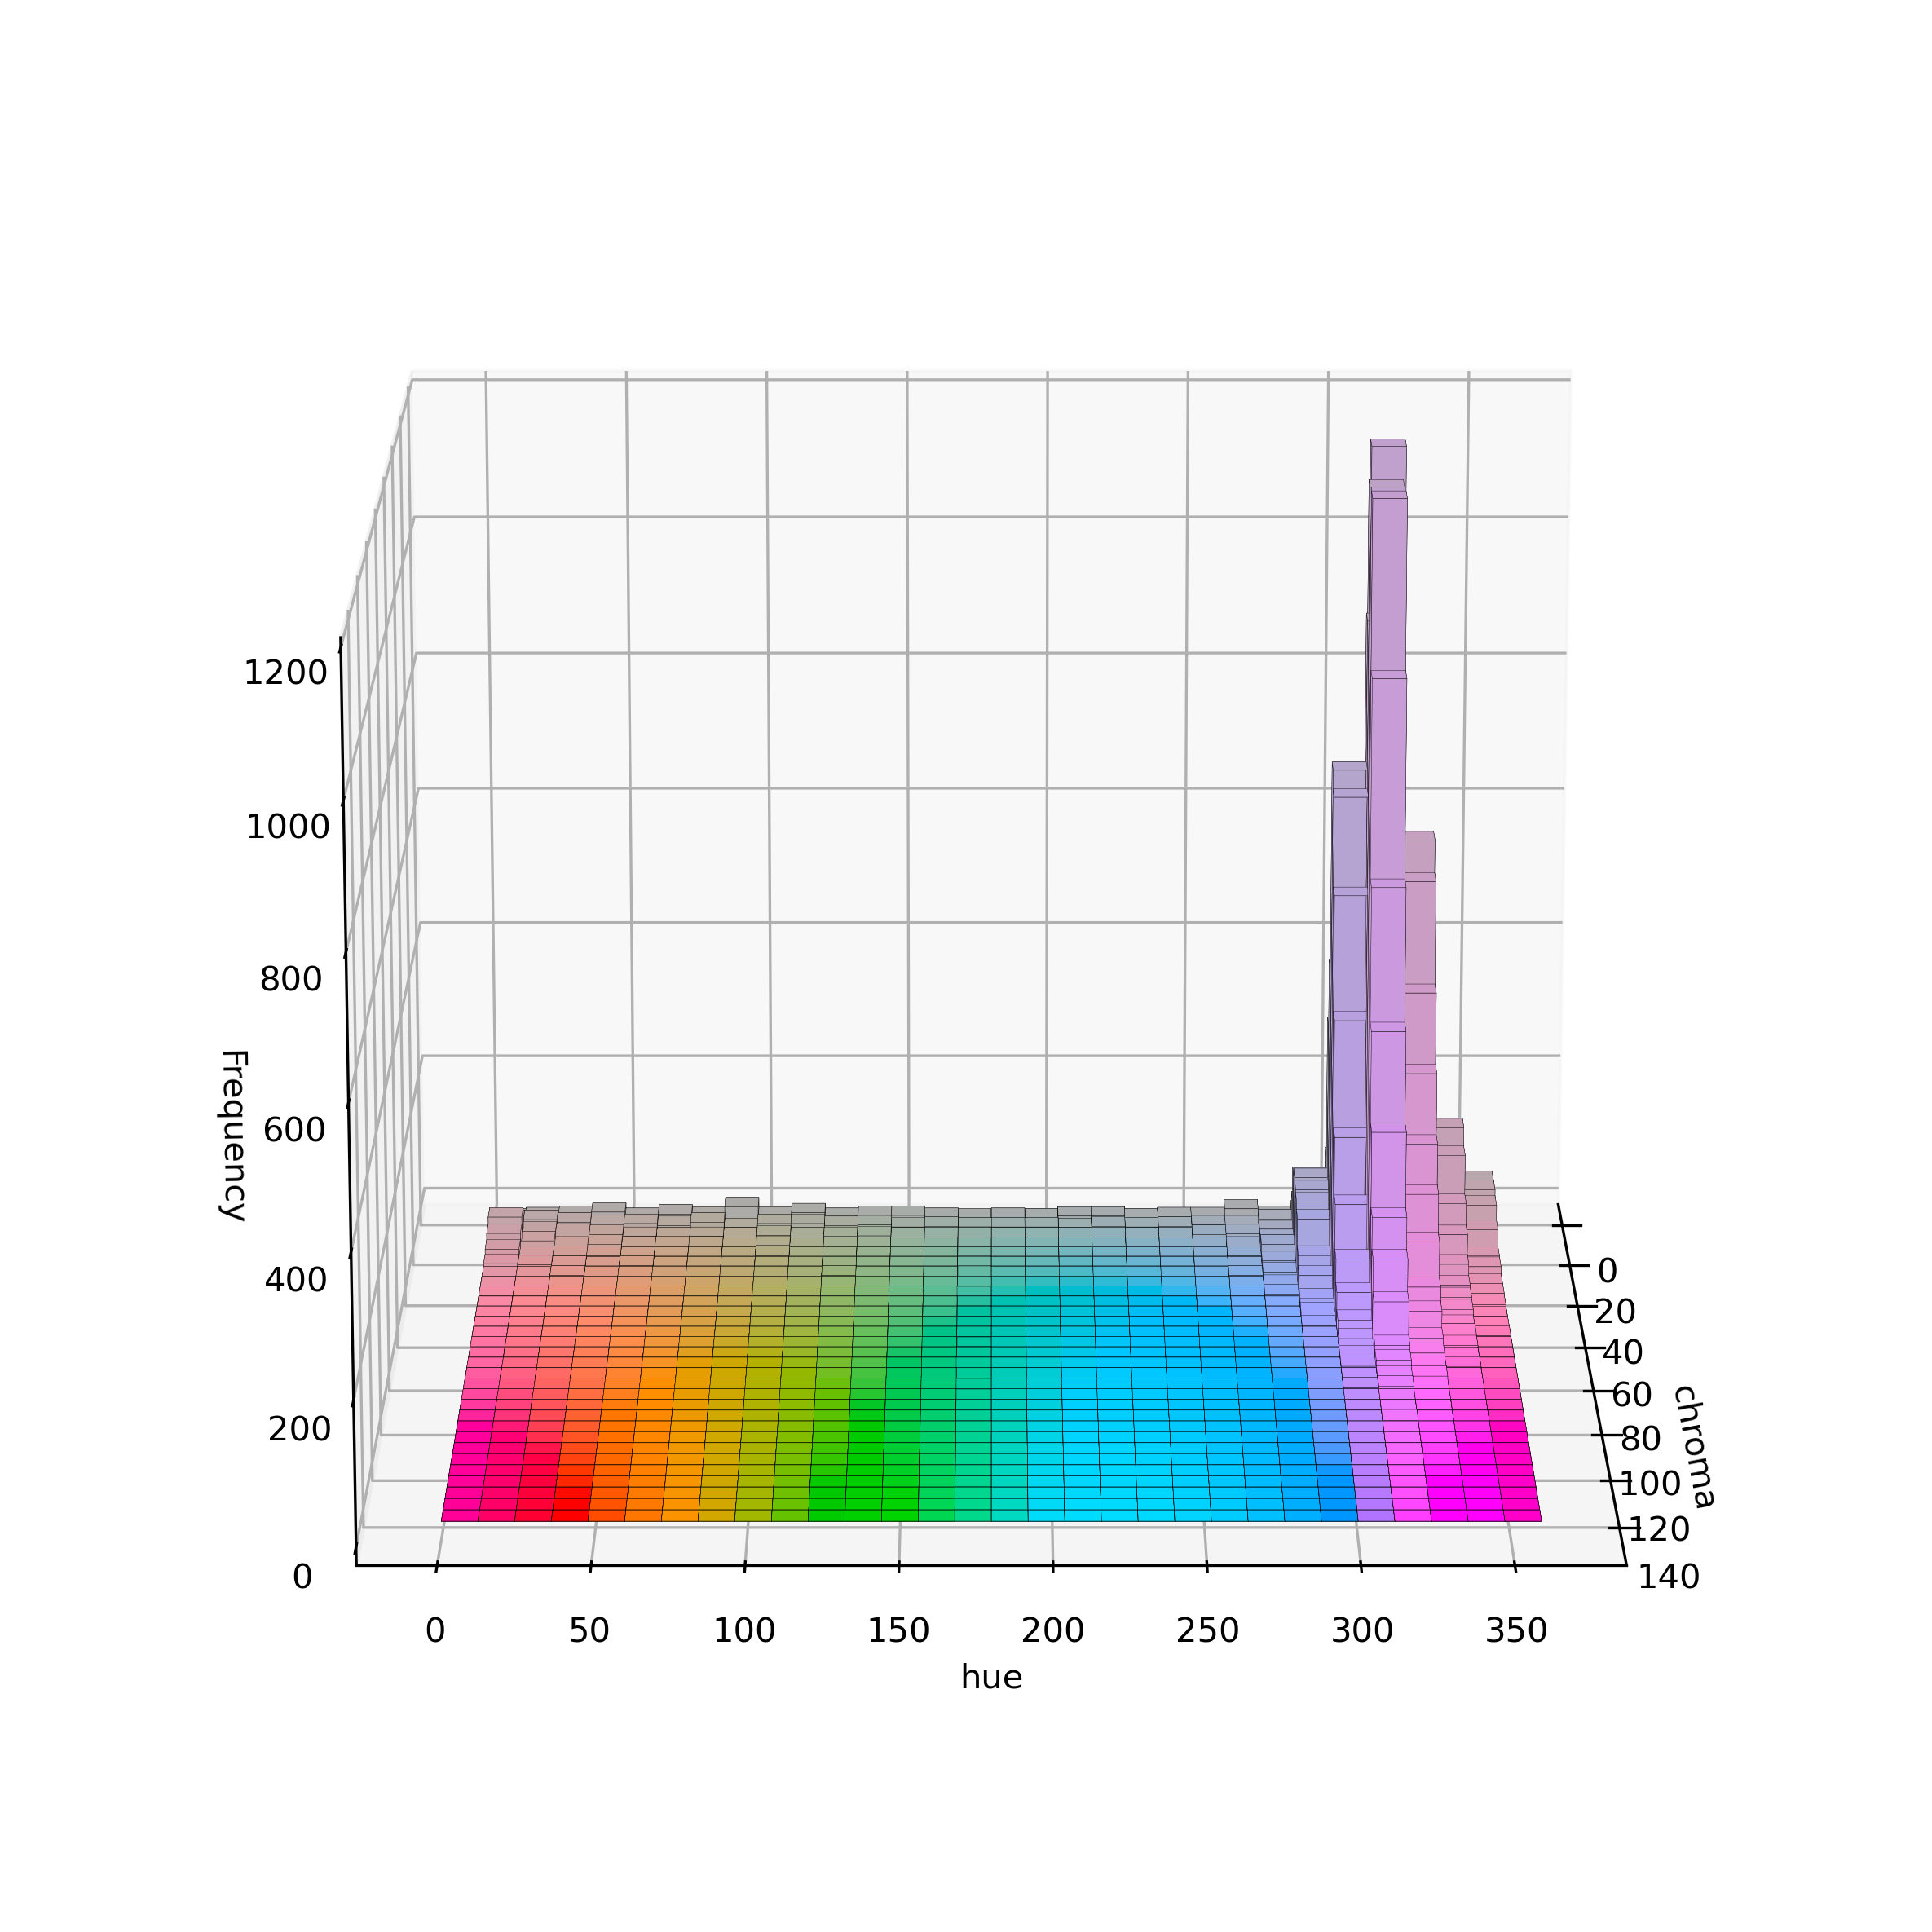

In [11]:
# convert entire grid to srgb.... I think  this is what bar3d is going to want
flat_rgb = lab2rgb(mean_lab[np.newaxis, ...]).reshape(-1, 3)

# line up all of our data
xpos, ypos = np.meshgrid(xedges[:-1], yedges[:-1], indexing='ij')
xpos = xpos.ravel(); ypos = ypos.ravel()
#xpos = xpos.flatten(); ypos = ypos.flatten()
zpos = np.zeros_like(xpos)
dx = (xedges[1] - xedges[0]) * np.ones_like(zpos)
dy = (yedges[1] - yedges[0]) * np.ones_like(zpos)
dz = hist.ravel()

# plot
fig = plt.figure(figsize=(10, 8),dpi=300)
ax = fig.add_subplot(111, projection='3d')
ax.bar3d(xpos, ypos, zpos, dx, dy, dz,
         color=flat_rgb,
         shade=False,
         edgecolor='black',
         linewidth=.1)

ax.set_xlabel('chroma')
ax.set_ylabel('hue')
ax.set_zlabel('Frequency')
ax.view_init(elev=15, azim=0)
plt.tight_layout()
plt.savefig('../figures/figures_current/components/figure_s3_0.pdf',dpi=300)
plt.show()

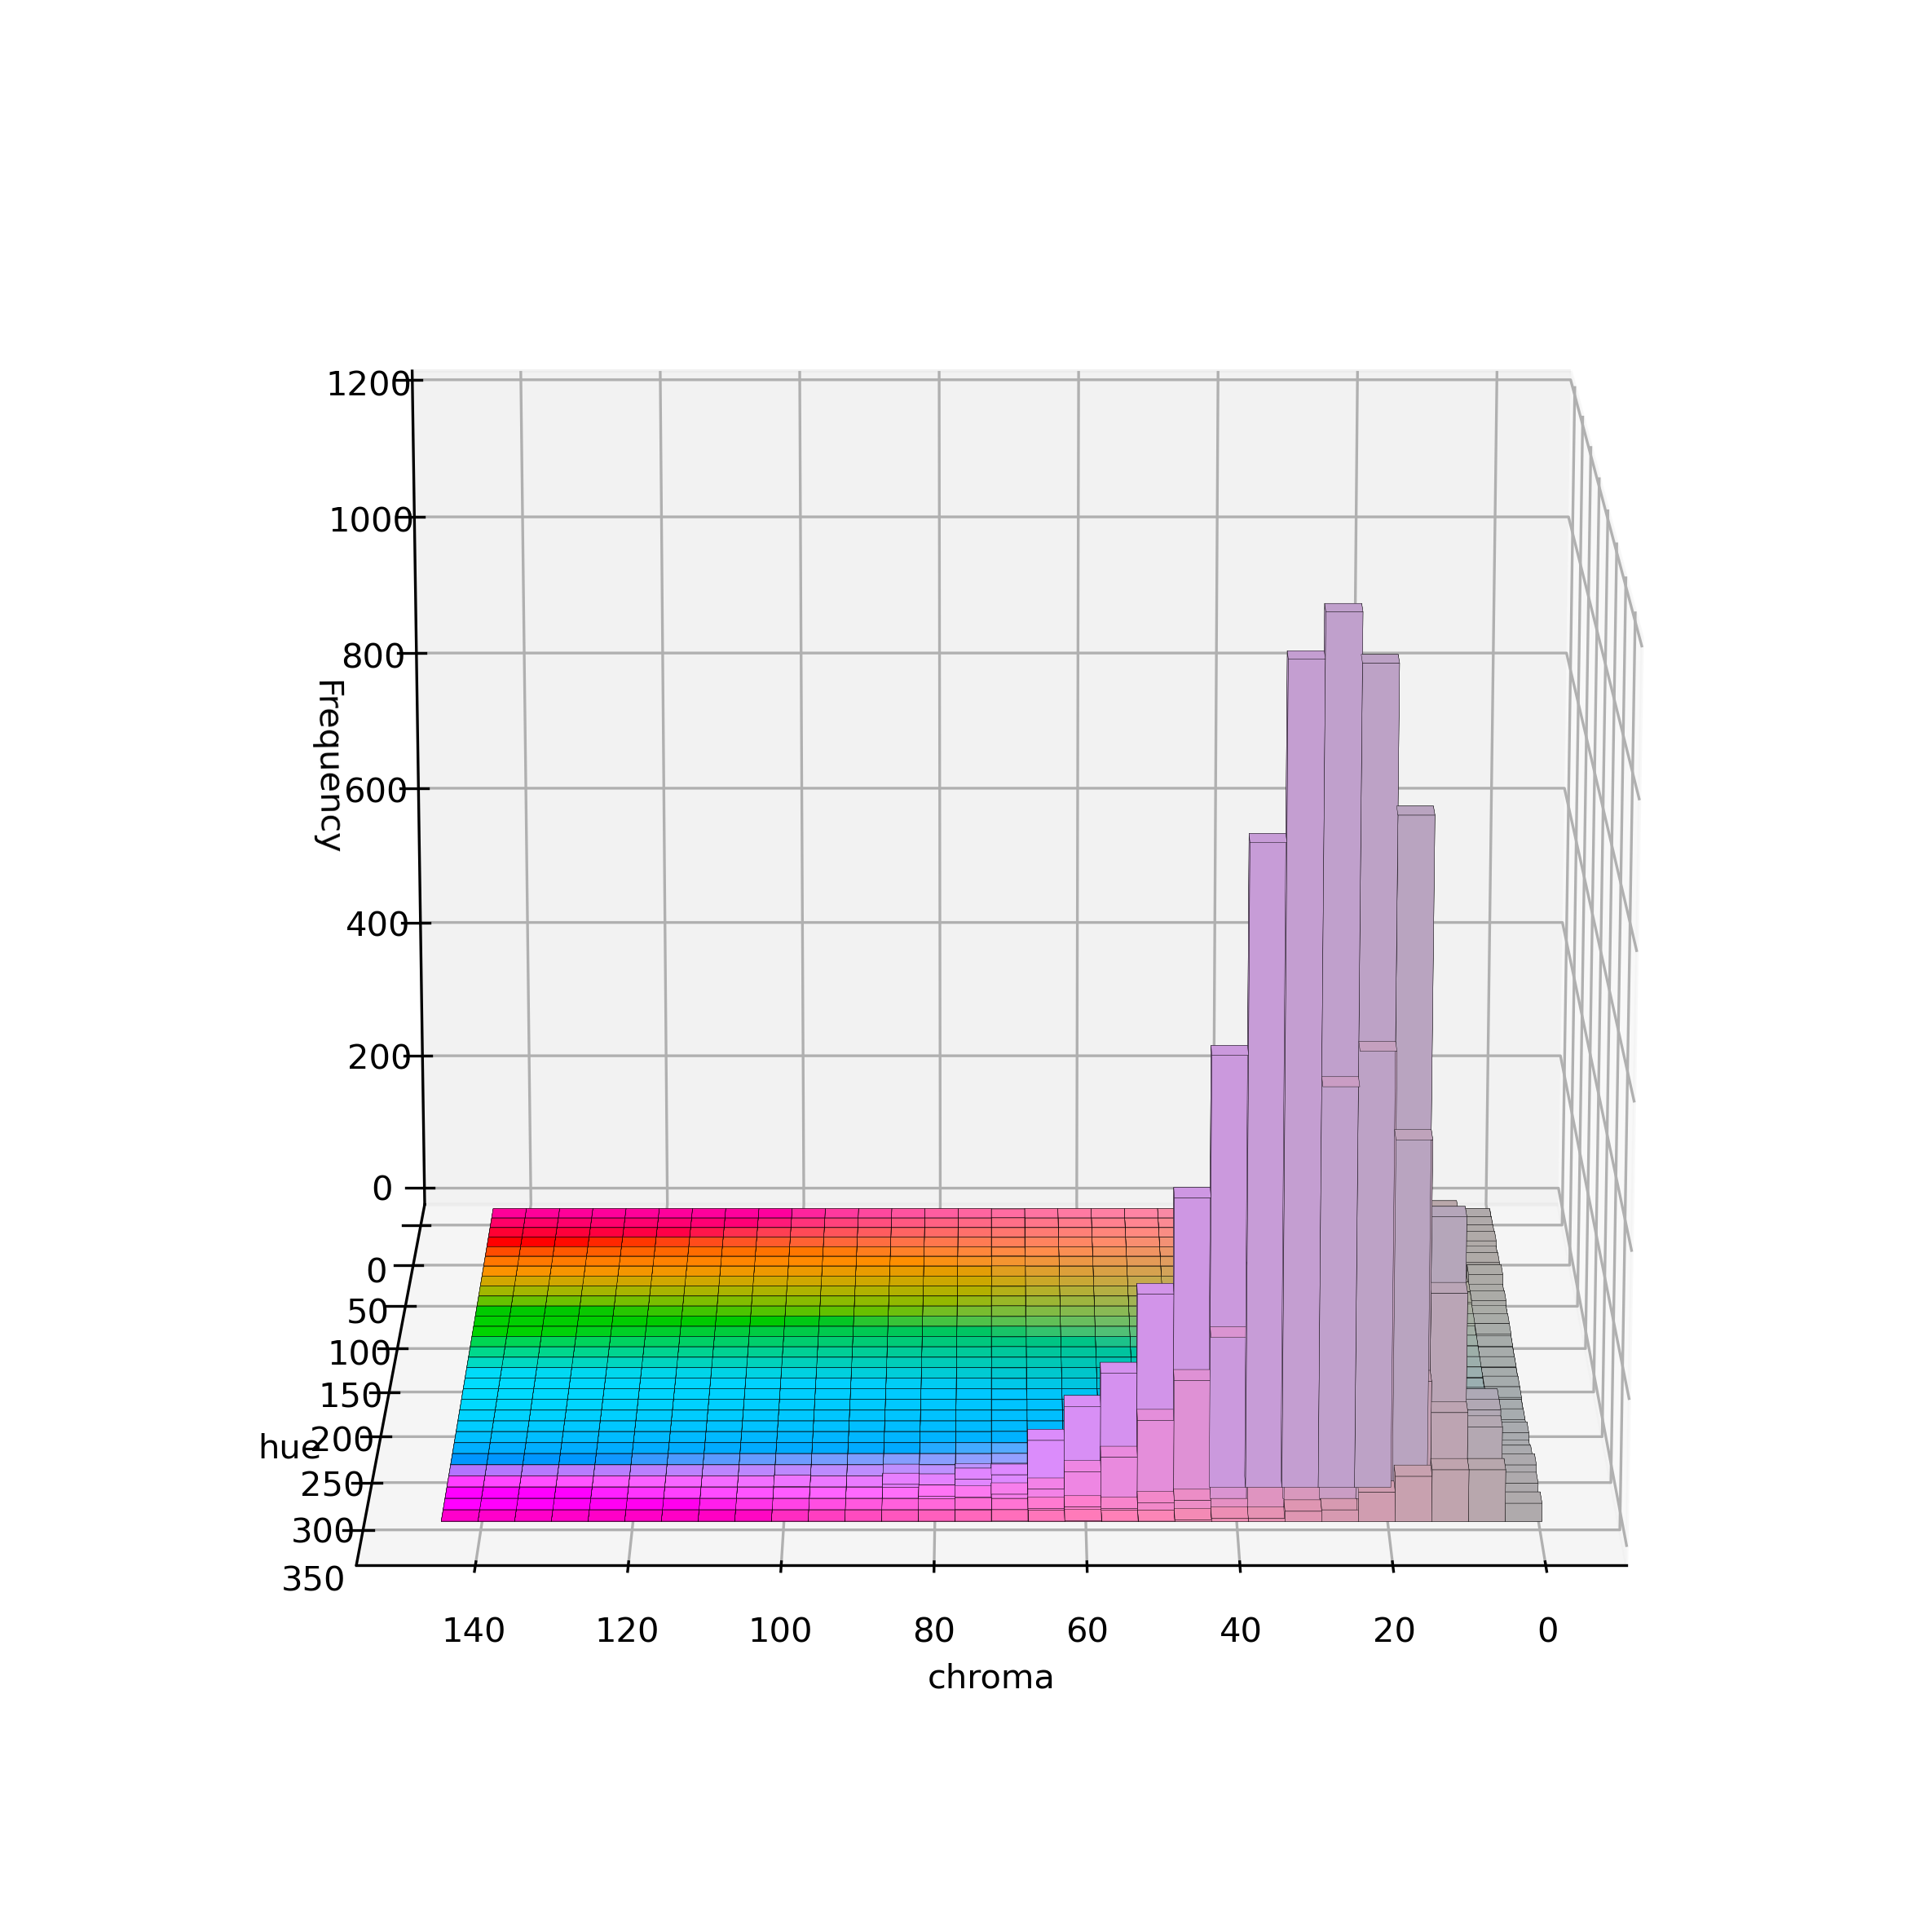

In [12]:
# convert entire grid to srgb.... I think  this is what bar3d is going to want
flat_rgb = lab2rgb(mean_lab[np.newaxis, ...]).reshape(-1, 3)

# line up all of our data
xpos, ypos = np.meshgrid(xedges[:-1], yedges[:-1], indexing='ij')
xpos = xpos.ravel(); ypos = ypos.ravel()
#xpos = xpos.flatten(); ypos = ypos.flatten()
zpos = np.zeros_like(xpos)
dx = (xedges[1] - xedges[0]) * np.ones_like(zpos)
dy = (yedges[1] - yedges[0]) * np.ones_like(zpos)
dz = hist.ravel()

# plot
fig = plt.figure(figsize=(10, 8),dpi=300)
ax = fig.add_subplot(111, projection='3d')
ax.bar3d(xpos, ypos, zpos, dx, dy, dz,
         color=flat_rgb,
         shade=False,
         edgecolor='black',
         linewidth=.1)

ax.set_xlabel('chroma')
ax.set_ylabel('hue')
ax.set_zlabel('Frequency')
ax.view_init(elev=15, azim=90)
plt.tight_layout()
plt.savefig('../figures/figures_current/components/figure_s3_90.pdf',dpi=300)
plt.show()

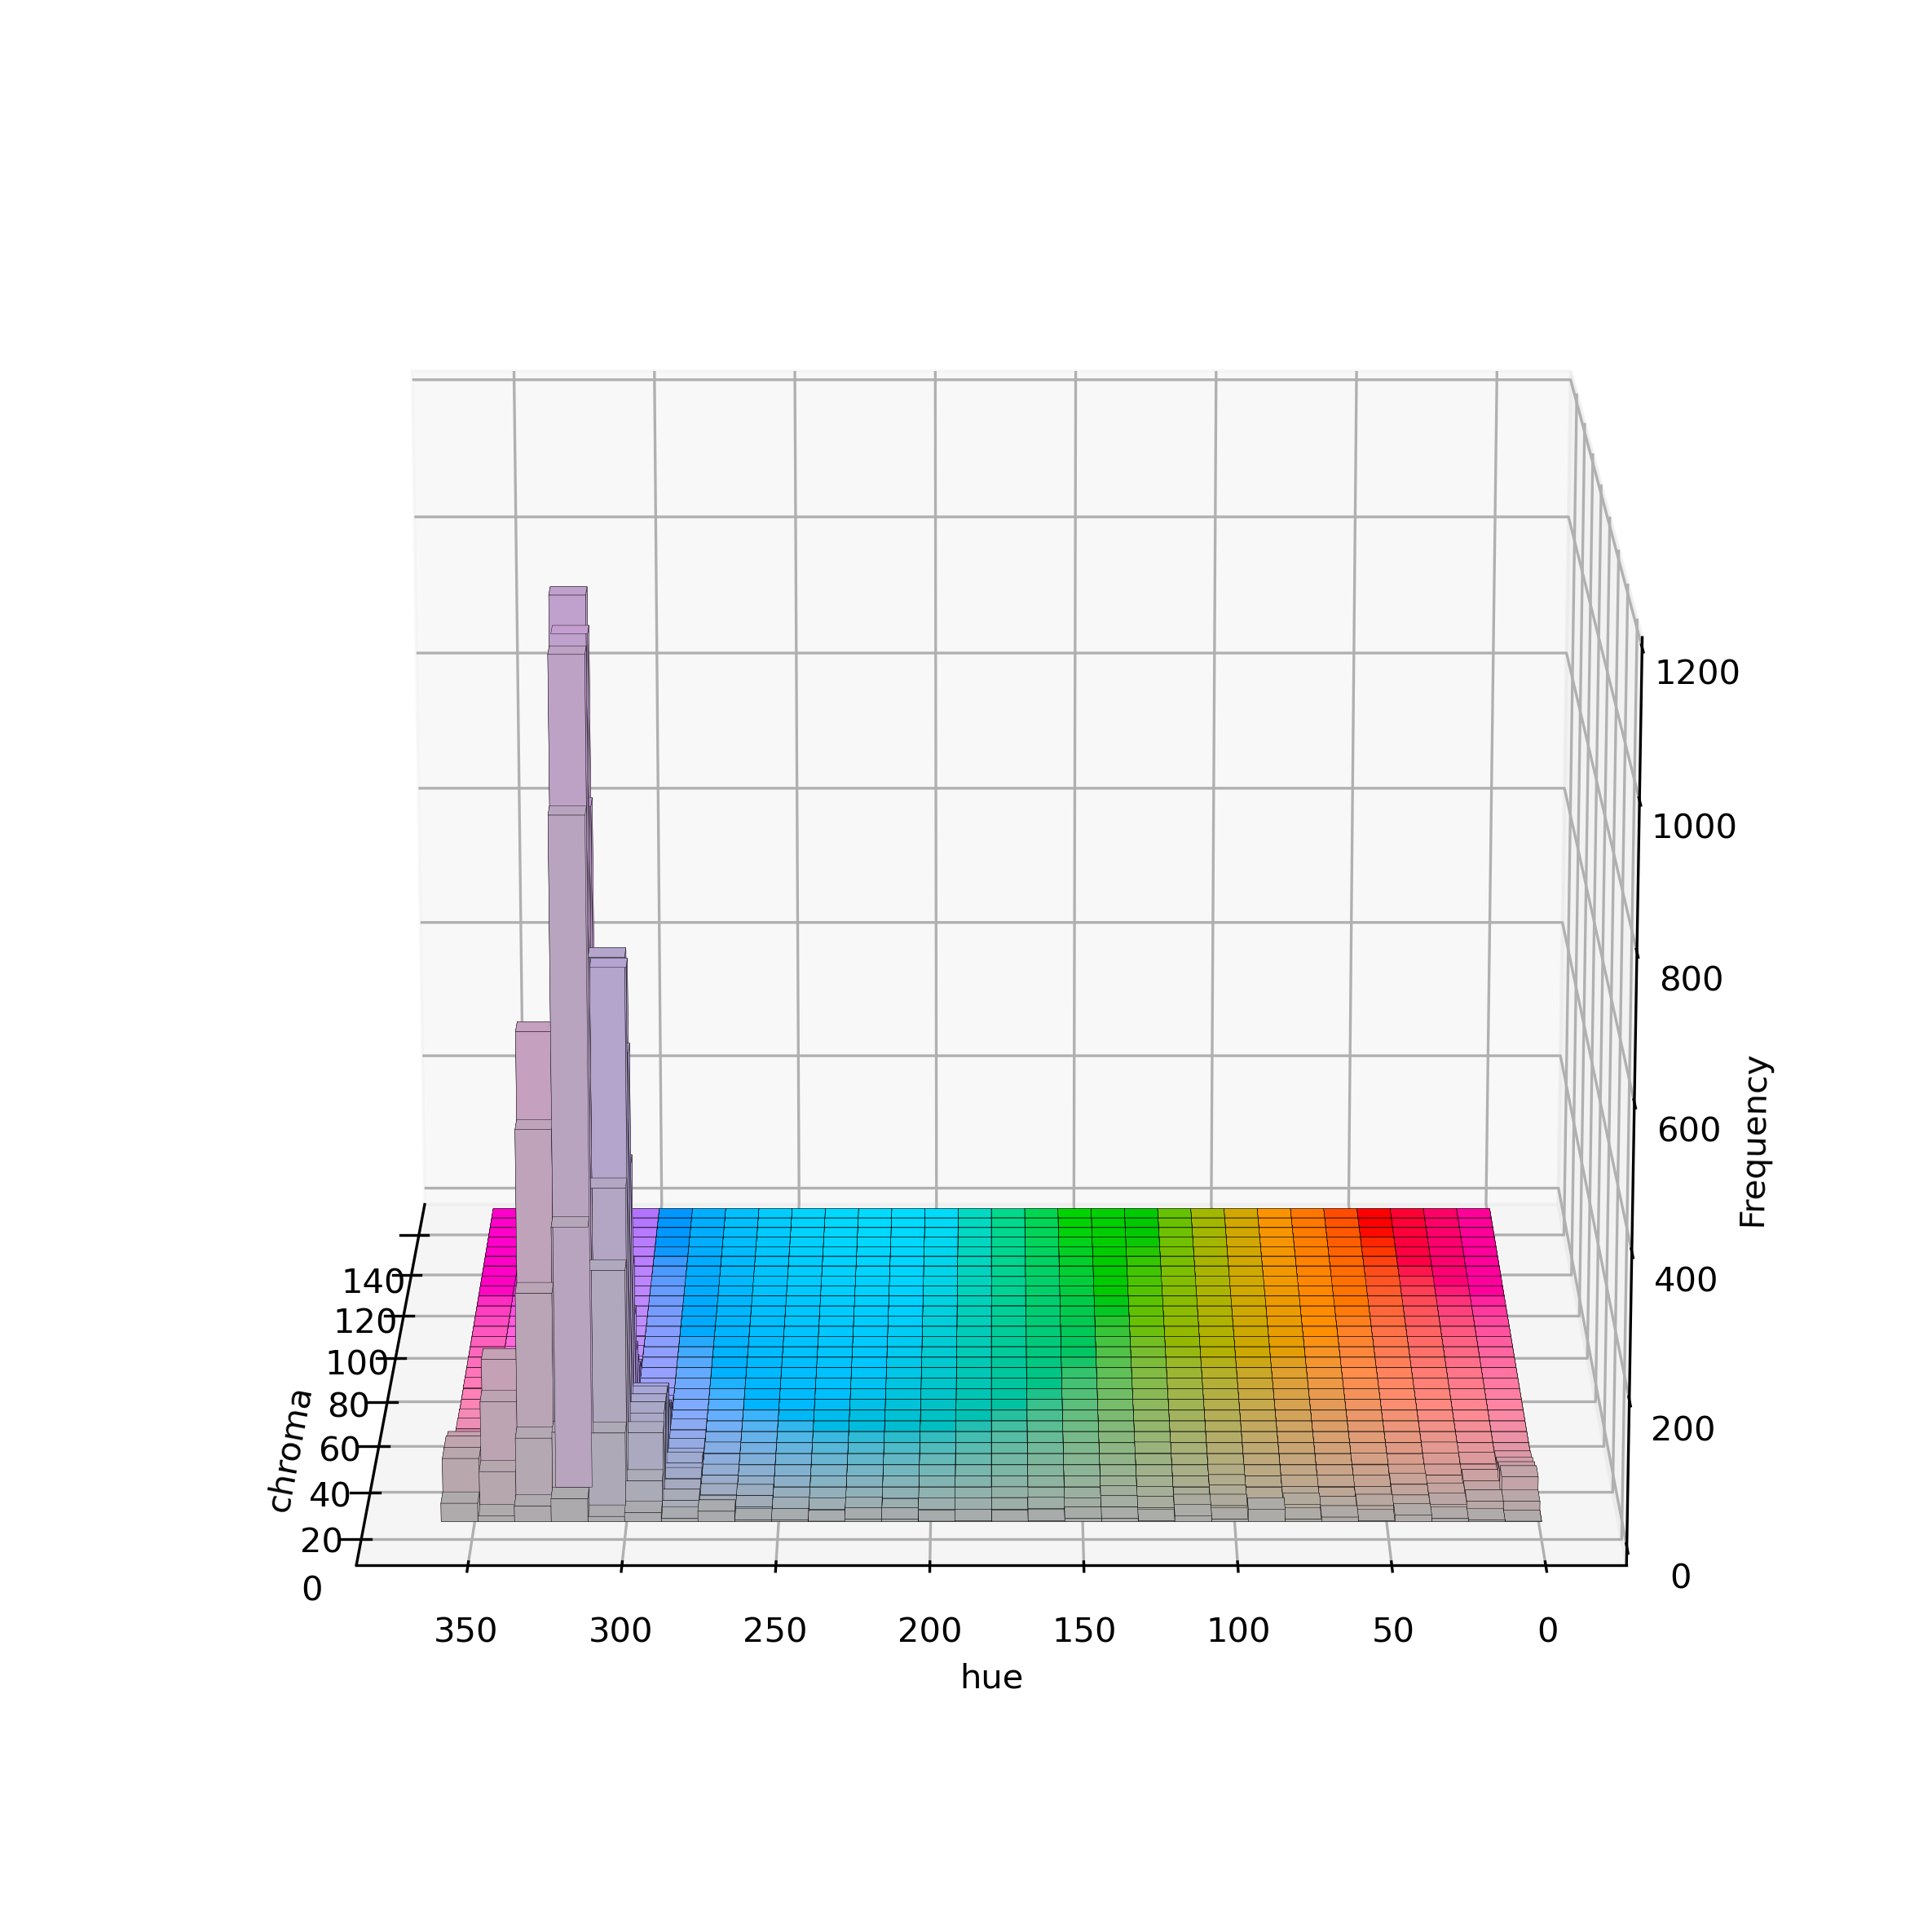

In [13]:
# convert entire grid to srgb.... I think  this is what bar3d is going to want
flat_rgb = lab2rgb(mean_lab[np.newaxis, ...]).reshape(-1, 3)

# line up all of our data
xpos, ypos = np.meshgrid(xedges[:-1], yedges[:-1], indexing='ij')
xpos = xpos.ravel(); ypos = ypos.ravel()
#xpos = xpos.flatten(); ypos = ypos.flatten()
zpos = np.zeros_like(xpos)
dx = (xedges[1] - xedges[0]) * np.ones_like(zpos)
dy = (yedges[1] - yedges[0]) * np.ones_like(zpos)
dz = hist.ravel()

# plot
fig = plt.figure(figsize=(10, 8),dpi=300)
ax = fig.add_subplot(111, projection='3d')
ax.bar3d(xpos, ypos, zpos, dx, dy, dz,
         color=flat_rgb,
         shade=False,
         edgecolor='black',
         linewidth=.1)

ax.set_xlabel('chroma')
ax.set_ylabel('hue')
ax.set_zlabel('Frequency')
ax.view_init(elev=15, azim=180)
plt.tight_layout()
plt.savefig('../figures/figures_current/components/figure_s3_180.pdf',dpi=300)
plt.show()

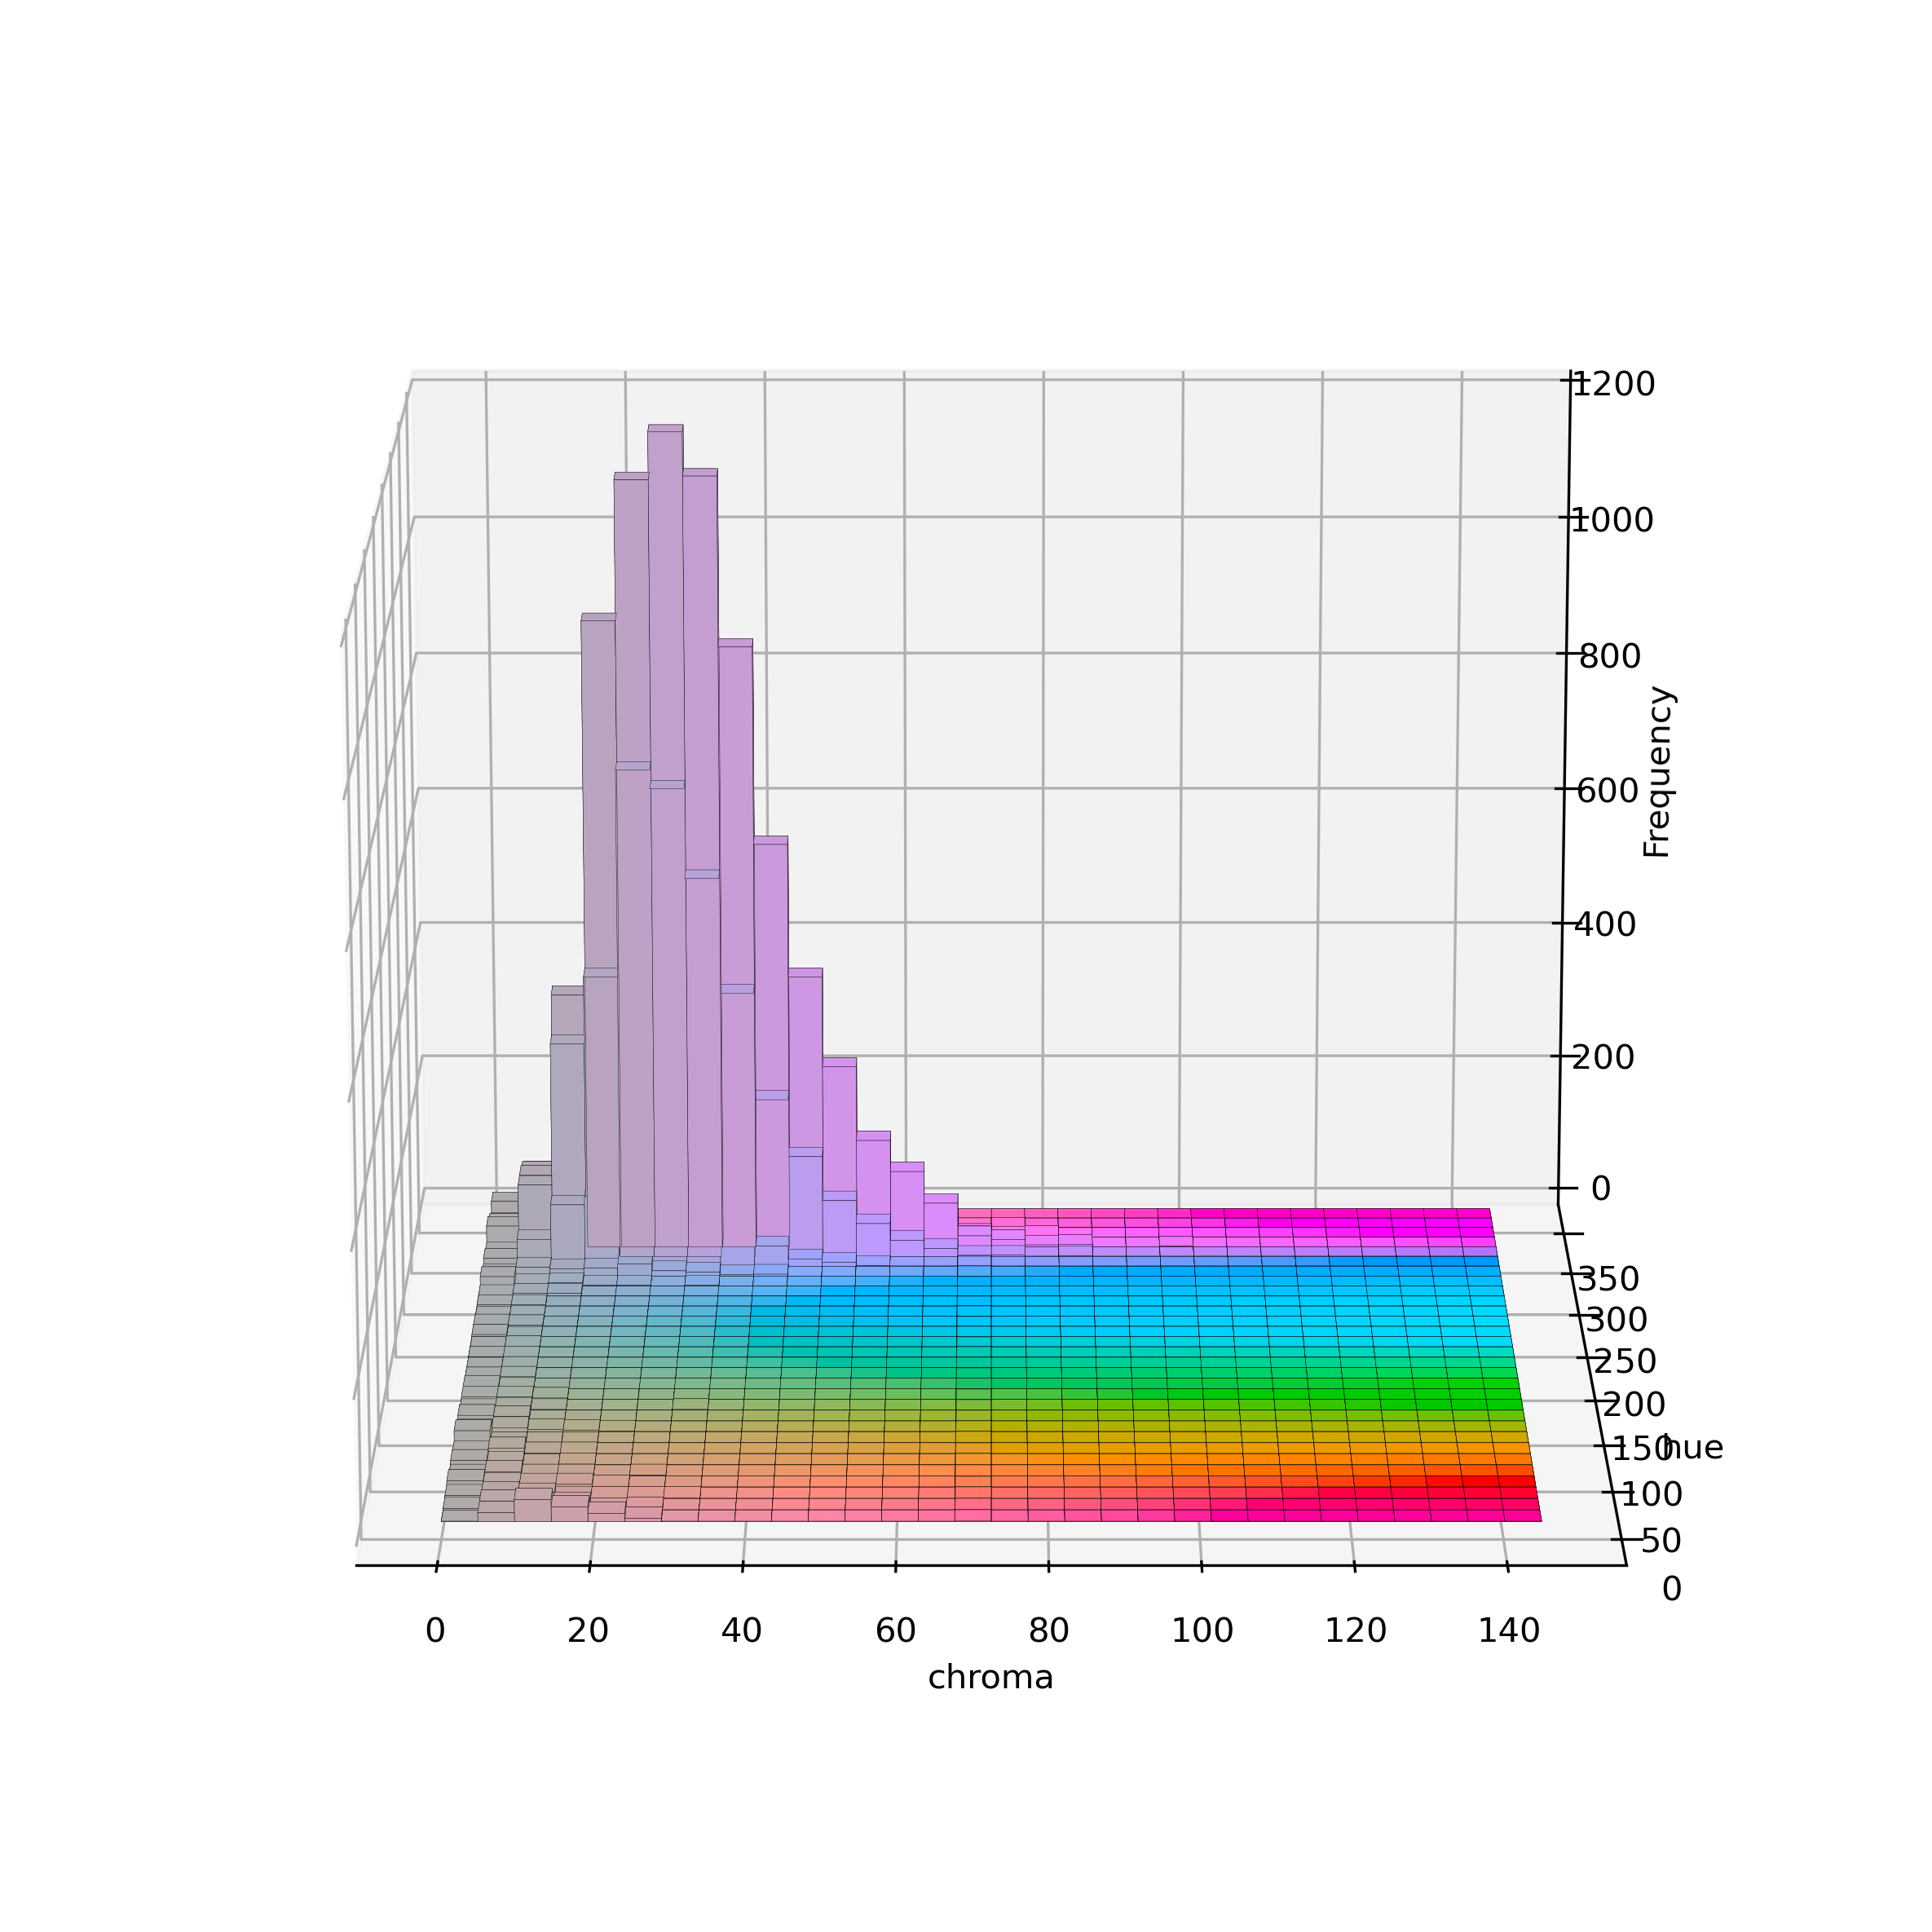

In [14]:
# convert entire grid to srgb.... I think  this is what bar3d is going to want
flat_rgb = lab2rgb(mean_lab[np.newaxis, ...]).reshape(-1, 3)

# line up all of our data
xpos, ypos = np.meshgrid(xedges[:-1], yedges[:-1], indexing='ij')
xpos = xpos.ravel(); ypos = ypos.ravel()
#xpos = xpos.flatten(); ypos = ypos.flatten()
zpos = np.zeros_like(xpos)
dx = (xedges[1] - xedges[0]) * np.ones_like(zpos)
dy = (yedges[1] - yedges[0]) * np.ones_like(zpos)
dz = hist.ravel()

# plot
fig = plt.figure(figsize=(10, 8),dpi=300)
ax = fig.add_subplot(111, projection='3d')
ax.bar3d(xpos, ypos, zpos, dx, dy, dz,
         color=flat_rgb,
         shade=False,
         edgecolor='black',
         linewidth=.1)

ax.set_xlabel('chroma')
ax.set_ylabel('hue')
ax.set_zlabel('Frequency')
ax.view_init(elev=15, azim=270)
plt.tight_layout()
plt.savefig('../figures/figures_current/components/figure_s3_270.pdf',dpi=300)
plt.show()